# 🐍 Snake Detector — Complete Training Notebook
**Dataset:** aishanikaggle/indian-snake (Kaggle)

**Output:** Bounding boxes + venomous/non_venomous labels

**Deploy:** Raspberry Pi 4 via NCNN

---
**Before starting:** Go to Runtime → Change runtime type → **T4 GPU**

In [1]:
# CELL 1: Install dependencies
!pip install -q ultralytics==8.3.40 opendatasets pyyaml
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU! Fix this!'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 17.5 MB/s eta 0:00:00
GPU: Tesla T4


In [2]:
# CELL 2: Download dataset from Kaggle
# It will ask for your Kaggle username + API key
# Get key from: kaggle.com → Profile → Settings → API → Create New Token
import opendatasets as od
od.download("https://www.kaggle.com/datasets/aishanikaggle/indian-snake")
print("✅ Dataset downloaded!")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mridulsk
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/aishanikaggle/indian-snake


100%|██████████| 169M/169M [00:00<00:00, 204MB/s]



✅ Dataset downloaded!


In [3]:
# CELL 3: Scan what was downloaded and find the correct paths
import os
from pathlib import Path

# Auto-detect the dataset folder
SRC = None
for item in os.listdir("."):
    if os.path.isdir(item) and "snake" in item.lower():
        SRC = item
        break

if SRC is None:
    # Try common opendatasets paths
    for candidate in ["indian-snake", "Indian-Snake", "indian_snake"]:
        if os.path.isdir(candidate):
            SRC = candidate
            break

if SRC is None:
    print("❌ Dataset folder not found! Check Cell 2 output.")
    print("All folders in current directory:")
    for x in os.listdir("."): print(f"  {x}")
else:
    print(f"✅ Dataset folder: {SRC}/")
    print(f"\nContents:")
    for sub in sorted(os.listdir(SRC)):
        full = os.path.join(SRC, sub)
        if os.path.isdir(full):
            count = len([f for f in os.listdir(full) if os.path.isfile(os.path.join(full, f))])
            subdirs = len([f for f in os.listdir(full) if os.path.isdir(os.path.join(full, f))])
            print(f"  📁 {sub}/ ({count} files, {subdirs} subdirs)")
        else:
            print(f"  📄 {sub}")

✅ Dataset folder: indian-snake/

Contents:
  📁 snake_dataset/ (0 files, 17 subdirs)


In [4]:
# CELL 4: Organize dataset — map species to venomous/non_venomous
import shutil, glob, random

IMAGE_EXT = {'.jpg','.jpeg','.png','.bmp','.webp'}
OUT = "snake_yolo_dataset"
SPLIT = 0.80
CLASS_TO_ID = {"venomous": 0, "non_venomous": 1}

# Keywords to detect venomous species from folder names
VENOMOUS_KEYS = ["cobra", "krait", "viper", "vipper", "pit", "cat_ven",
                 "cat ven", "venoumous", "venomous"]
NON_VENOMOUS_KEYS = ["python", "rat", "racer", "wolf", "keelback", "kukri",
                     "boa", "trinket", "royal", "black", "non-veno", "non_veno",
                     "nonveno"]

def classify_folder(name):
    low = name.lower().replace("_", " ").replace("-", " ")
    # Check non-venomous FIRST (because "non-venomous" contains "venomous")
    for k in NON_VENOMOUS_KEYS:
        if k in low:
            return "non_venomous"
    for k in VENOMOUS_KEYS:
        if k in low:
            return "venomous"
    return None

# Walk through ALL folders and subfolders to find images
all_images = []
seen_files = set()

for root, dirs, files in os.walk(SRC):
    folder_name = os.path.basename(root)
    cls = classify_folder(folder_name)

    # If this folder itself isn't classified, try parent
    if cls is None:
        parent = os.path.basename(os.path.dirname(root))
        cls = classify_folder(parent)

    if cls is None:
        continue

    for f in files:
        if Path(f).suffix.lower() in IMAGE_EXT:
            key = f.lower()
            if key not in seen_files:
                seen_files.add(key)
                all_images.append((os.path.join(root, f), cls))

ven = sum(1 for _, c in all_images if c == "venomous")
nven = sum(1 for _, c in all_images if c == "non_venomous")
print(f"✅ Collected: {len(all_images)} images")
print(f"   🔴 Venomous:     {ven}")
print(f"   🟢 Non-venomous: {nven}")

if len(all_images) == 0:
    print("\n❌ No images found! Check SRC folder path.")

✅ Collected: 3394 images
   🔴 Venomous:     1251
   🟢 Non-venomous: 2143


In [5]:
# CELL 5: Auto-generate bounding boxes using pretrained YOLO
from ultralytics import YOLO
import cv2

print("Generating bounding boxes (takes ~5 min)...")
auto_model = YOLO("yolov8n.pt")

annotations = {}
fallback_count = 0
detected_count = 0

for idx, (img_path, cls) in enumerate(all_images):
    if idx % 300 == 0:
        print(f"  {idx+1}/{len(all_images)}...")
    try:
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        results = auto_model.predict(img_path, imgsz=320, conf=0.15, verbose=False)
        best_box = None
        best_area = 0
        for r in results:
            if r.boxes is not None and len(r.boxes) > 0:
                for box in r.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    area = (x2 - x1) * (y2 - y1)
                    if area > best_area:
                        best_area = area
                        best_box = (x1, y1, x2, y2)
        if best_box is not None and best_area > (w * h * 0.01):
            x1, y1, x2, y2 = best_box
            cx = max(0, min(1, ((x1 + x2) / 2) / w))
            cy = max(0, min(1, ((y1 + y2) / 2) / h))
            bw = max(0.05, min(1, (x2 - x1) / w))
            bh = max(0.05, min(1, (y2 - y1) / h))
            detected_count += 1
        else:
            cx, cy, bw, bh = 0.5, 0.5, 0.85, 0.85
            fallback_count += 1
        annotations[img_path] = (cls, cx, cy, bw, bh)
    except Exception as e:
        annotations[img_path] = (cls, 0.5, 0.5, 0.85, 0.85)
        fallback_count += 1

print(f"\n✅ Done! {detected_count} auto-detected, {fallback_count} center-fallback")
print(f"   Total annotations: {len(annotations)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Generating bounding boxes (takes ~5 min)...


100%|██████████| 6.25M/6.25M [00:00<00:00, 85.8MB/s]


  1/3394...
  301/3394...
  601/3394...
  901/3394...
  1201/3394...
  1501/3394...
  1801/3394...
  2101/3394...
  2401/3394...
  2701/3394...
  3001/3394...
  3301/3394...

✅ Done! 1941 auto-detected, 1453 center-fallback
   Total annotations: 3394


In [6]:
# CELL 6: Create YOLO dataset structure + data.yaml
import yaml

for split in ["train", "val"]:
    os.makedirs(f"{OUT}/{split}/images", exist_ok=True)
    os.makedirs(f"{OUT}/{split}/labels", exist_ok=True)

items = list(annotations.items())
random.seed(42)
random.shuffle(items)
split_idx = int(len(items) * SPLIT)
train_items = items[:split_idx]
val_items = items[split_idx:]

def write_split(items, split_name):
    count = 0
    for i, (img_path, (cls, cx, cy, bw, bh)) in enumerate(items):
        try:
            ext = Path(img_path).suffix
            fname = f"{split_name}_{i:05d}"
            shutil.copy2(img_path, f"{OUT}/{split_name}/images/{fname}{ext}")
            class_id = CLASS_TO_ID[cls]
            with open(f"{OUT}/{split_name}/labels/{fname}.txt", "w") as f:
                f.write(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
            count += 1
        except Exception as e:
            print(f"  Skip {img_path}: {e}")
    return count

tc = write_split(train_items, "train")
vc = write_split(val_items, "val")

data_yaml = {
    "path": os.path.abspath(OUT),
    "train": "train/images",
    "val": "val/images",
    "nc": 2,
    "names": ["venomous", "non_venomous"]
}
with open(f"{OUT}/data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ Dataset ready!")
print(f"   Train: {tc} images")
print(f"   Val:   {vc} images")
print(f"   Classes: venomous(0), non_venomous(1)")
print(f"   data.yaml: {OUT}/data.yaml")

✅ Dataset ready!
   Train: 2715 images
   Val:   679 images
   Classes: venomous(0), non_venomous(1)
   data.yaml: snake_yolo_dataset/data.yaml


In [7]:
# CELL 7: TRAIN YOLOv8n
from ultralytics import YOLO
import os
HOME = os.getcwd()

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{HOME}/{OUT}/data.yaml",
    imgsz=320,
    epochs=150,
    batch=16,
    device=0,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    augment=True,
    mosaic=1.0,
    mixup=0.2,
    degrees=30.0,
    translate=0.2,
    scale=0.5,
    flipud=0.5,
    fliplr=0.5,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    patience=30,
    cos_lr=True,
    project="runs",
    name="snake_det",
    exist_ok=True,
    verbose=True,
)
print(f"\n✅ TRAINING DONE!")
print(f"Best weights: {HOME}/runs/snake_det/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/snake_yolo_dataset/data.yaml, epochs=150, time=None, patience=30, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=snake_det, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, s

100%|██████████| 755k/755k [00:00<00:00, 18.7MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 77.7MB/s]


AMP: checks passed ✅


...

    148/150     0.617G     0.5276     0.7668      1.195         11        320: 100%|██████████| 170/170 [00:23<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:03<00:00,  6.36it/s]

                   all        679        679      0.718      0.704      0.734      0.525
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 118, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



148 epochs completed in 1.275 hours.
Optimizer stripped from runs/snake_det/weights/last.pt, 6.2MB
Optimizer stripped from runs/snake_det/weights/best.pt, 6.2MB

Validating runs/snake_det/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:06<00:00,  3.54it/s]


                   all        679        679      0.755      0.683      0.767      0.585
              venomous        247        247      0.746       0.64      0.751      0.591
          non_venomous        432        432      0.764      0.727      0.783      0.578
Speed: 0.1ms preprocess, 3.3ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/snake_det

✅ TRAINING DONE!
Best weights: /content/runs/snake_det/weights/best.pt


In [8]:
# CELL 8: Validate
best_pt = f"{HOME}/runs/snake_det/weights/best.pt"
model = YOLO(best_pt)
metrics = model.val(data=f"{HOME}/{OUT}/data.yaml", imgsz=320)
print(f"\nmAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/snake_yolo_dataset/val/labels.cache... 679 images, 0 backgrounds, 0 corrupt: 100%|██████████| 679/679 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 43/43 [00:04<00:00,  9.48it/s]


                   all        679        679      0.717      0.697      0.754       0.54
              venomous        247        247      0.693      0.692      0.736      0.553
          non_venomous        432        432      0.741      0.703      0.771      0.527
Speed: 0.1ms preprocess, 1.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val

mAP50:     0.7537
mAP50-95:  0.5402
Precision: 0.7169
Recall:    0.6975



image 1/679 /content/snake_yolo_dataset/val/images/val_00000.jpg: 320x320 (no detections), 10.0ms
image 2/679 /content/snake_yolo_dataset/val/images/val_00001.jpg: 320x320 1 non_venomous, 12.9ms
image 3/679 /content/snake_yolo_dataset/val/images/val_00002.jpg: 320x320 1 non_venomous, 10.3ms
image 4/679 /content/snake_yolo_dataset/val/images/val_00003.jpg: 320x320 1 non_venomous, 9.9ms
image 5/679 /content/snake_yolo_dataset/val/images/val_00004.jpg: 320x320 1 non_venomous, 9.7ms
image 6/679 /content/snake_yolo_dataset/val/images/val_00005.jpg: 320x320 1 non_venomous, 10.0ms
image 7/679 /content/snake_yolo_dataset/val/images/val_00006.jpg: 320x320 1 venomous, 1 non_venomous, 11.5ms
image 8/679 /content/snake_yolo_dataset/val/images/val_00007.jpg: 320x320 1 non_venomous, 10.9ms
image 9/679 /content/snake_yolo_dataset/val/images/val_00008.jpg: 320x320 1 non_venomous, 12.6ms
image 10/679 /content/snake_yolo_dataset/val/images/val_00009.jpg: 320x320 1 non_venomous, 9.5ms
image 11/679 /cont

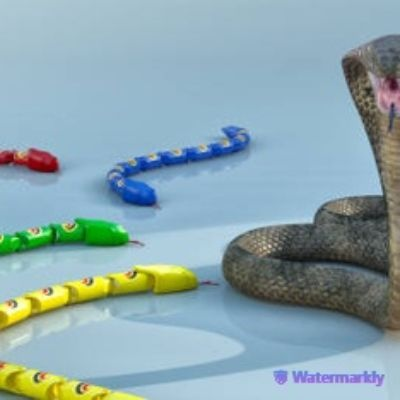


val_00001.jpg


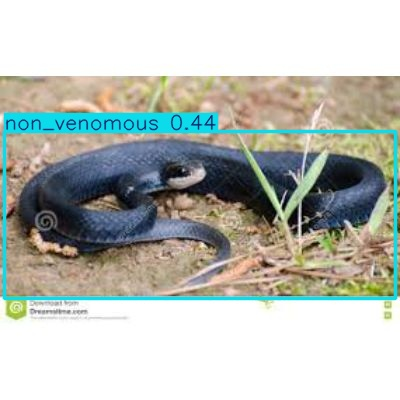


val_00002.jpg


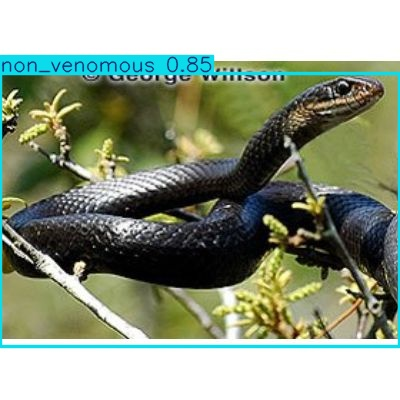


val_00003.jpg


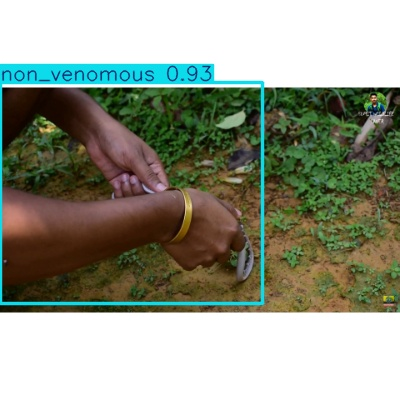


val_00004.jpg


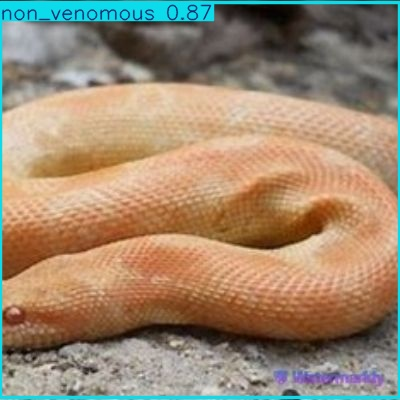


val_00005.jpg


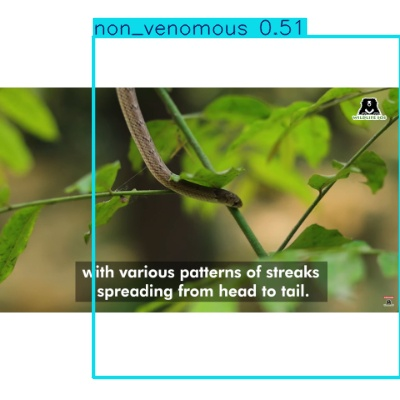


val_00006.jpg


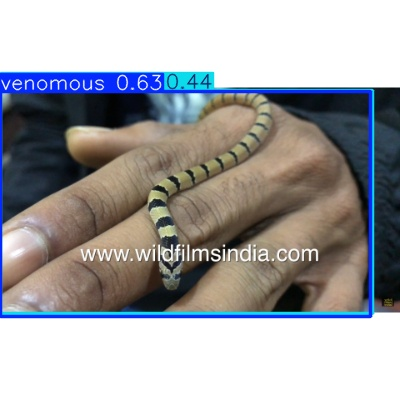


val_00007.jpg


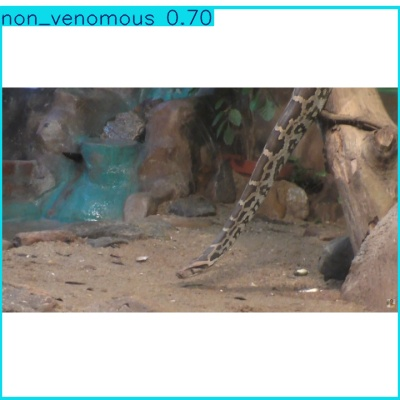


👆 Bounding boxes with venomous/non_venomous labels


In [9]:
# CELL 9: Test — SEE BOUNDING BOXES on images
from IPython.display import Image, display

pred_results = model.predict(
    source=f"{HOME}/{OUT}/val/images",
    imgsz=320,
    conf=0.4,
    save=True,
    project="runs",
    name="predictions",
    exist_ok=True,
)

pred_imgs = sorted(glob.glob(f"{HOME}/runs/predictions/*.jpg") +
                   glob.glob(f"{HOME}/runs/predictions/*.jpeg") +
                   glob.glob(f"{HOME}/runs/predictions/*.png"))[:8]

if pred_imgs:
    for p in pred_imgs:
        print(os.path.basename(p))
        display(Image(filename=p, width=500))
        print()
    print("👆 Bounding boxes with venomous/non_venomous labels")
else:
    print("No prediction images found. Check runs/predictions/ folder.")

In [11]:
# CELL 10: Export to NCNN (for Raspberry Pi)
# CELL 10: Export to NCNN (for Raspberry Pi)
print("Exporting to NCNN...")
export_model = YOLO(best_pt)
ncnn_path = export_model.export(format="ncnn", imgsz=320, half=False)
print(f"✅ NCNN exported: {ncnn_path}")

# Find NCNN model directory
ncnn_dir = None
known = f"{HOME}/runs/snake_det/weights/best_ncnn_model"
if os.path.isdir(known):
    ncnn_dir = known
else:
    for root, dirs, files_list in os.walk("."):
        for f in files_list:
            if f.endswith(".ncnn.param"):
                ncnn_dir = root
                break
        if ncnn_dir:
            break

print(f"\nNCNN model directory: {ncnn_dir}")
if ncnn_dir:
    for f in sorted(os.listdir(ncnn_dir)):
        fp = os.path.join(ncnn_dir, f)
        if os.path.isfile(fp):
            sz = os.path.getsize(fp) / 1024 / 1024
            print(f"  {f} ({sz:.2f} MB)")
else:
    print("❌ NCNN files not found!")


Exporting to NCNN...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/snake_det/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (5.9 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 1.3s, saved as '/content/runs/snake_det/weights/best.torchscript' (11.8 MB)

NCNN: starting export with NCNN 1.0.20260114...
NCNN: running '/usr/local/lib/python3.12/dist-packages/ultralytics/pnnx /content/runs/snake_det/weights/best.torchscript ncnnparam=/content/runs/snake_det/weights/best_ncnn_model/model.ncnn.param ncnnbin=/content/runs/snake_det/weights/best_ncnn_model/model.ncnn.bin ncnnpy=/content/runs/snake_det/weights/best_ncnn_model/model_ncnn.py pnnxparam=/content/runs/snake_det/weights/best_ncnn_model/model.pnnx.param pnnxbin=/content/runs/snake_det/weights/best_ncn

In [12]:
# CELL 11: Download model for Raspberry Pi
import shutil

deploy = "snake_model_for_pi"
if os.path.exists(deploy):
    shutil.rmtree(deploy)
os.makedirs(deploy)

# Copy NCNN model files
if ncnn_dir:
    for f in os.listdir(ncnn_dir):
        src_file = os.path.join(ncnn_dir, f)
        if os.path.isfile(src_file):
            shutil.copy(src_file, deploy)
            print(f"  Copied: {f}")

# Copy best.pt
if os.path.exists(best_pt):
    shutil.copy(best_pt, deploy)
    print(f"  Copied: best.pt")

# Model info
with open(f"{deploy}/README.txt", "w") as fp:
    fp.write("Snake Detector Model\n")
    fp.write("Model: YOLOv8n (Detection with bounding boxes)\n")
    fp.write("Input: 320x320\n")
    fp.write("Classes: 0=venomous, 1=non_venomous\n")
    try:
        fp.write(f"mAP50: {metrics.box.map50:.4f}\n")
    except:
        fp.write("mAP50: see training logs\n")
    fp.write("Dataset: aishanikaggle/indian-snake\n")

# Zip and download
shutil.make_archive(deploy, "zip", deploy)

from google.colab import files
files.download(f"{deploy}.zip")

print("\n✅ Downloading snake_model_for_pi.zip")
print("\nNext steps:")
print("1. Unzip the file")
print("2. Put .param + .bin files in BIO_MIMIC/models/")
print("3. On your PC: bash scripts/build_docker.sh")
print("4. Transfer to Pi and run!")

  Copied: metadata.yaml
  Copied: model.ncnn.bin
  Copied: model_ncnn.py
  Copied: model.ncnn.param
  Copied: best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloading snake_model_for_pi.zip

Next steps:
1. Unzip the file
2. Put .param + .bin files in BIO_MIMIC/models/
3. On your PC: bash scripts/build_docker.sh
4. Transfer to Pi and run!
